# 03 — CGAN Training

Treina um **Conditional GAN (CGAN)** para gerar imagens sintéticas de borboletas condicionadas à classe.

### Pipeline
1. Carregar dataset de treino
2. Inicializar Generator e Discriminator
3. Loop de treino adversarial com checkpoint saving
4. Visualizar amostras ao longo do treino
5. Guardar modelo final


In [6]:
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.utils as vutils
import torchvision.transforms as T
from torch.utils.data import DataLoader

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.path.abspath("__file__")).parent
SRC_DIR      = (NOTEBOOK_DIR / "../src").resolve()
CKPT_DIR     = (NOTEBOOK_DIR / "../outputs/checkpoints/gan").resolve()
SAMPLE_DIR   = (NOTEBOOK_DIR / "../outputs/figures/gan_samples").resolve()

sys.path.insert(0, str(SRC_DIR))

CKPT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset via kagglehub (mesmo método do notebook 00) ──────────────────────
import kagglehub
dataset_path = Path(kagglehub.competition_download("aca-tp-2"))

train_dir = dataset_path / "train"
test_dir  = dataset_path / "test"
train_csv_path = dataset_path / "train.csv"

print(f"Dataset path : {dataset_path}")
print(f"Train images : {len(list(train_dir.iterdir()))} ficheiros")
print(f"Device       : ", end="")

from gan1 import Generator, Discriminator, build_cgan, real_label, fake_label, LATENT_DIM
from dataset import ButterflyDataset
from utils   import get_splits, GLOBAL_SEED

device = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(device)
torch.manual_seed(GLOBAL_SEED)


Dataset path : /Users/ritapduarte/.cache/kagglehub/competitions/aca-tp-2
Train images : 5199 ficheiros
Device       : mps


## Hiperparâmetros

In [7]:
# ── Treino ──────────────────────────────────────────────────────────────────
NUM_EPOCHS      = 200        # epochs totais
BATCH_SIZE      = 64
LR_G            = 2e-4       # learning rate do Generator
LR_D            = 1e-4       # learning rate do Discriminator (ligeiramente menor para estabilidade)
BETA1           = 0.5        # Adam beta1 (standard para GANs)
BETA2           = 0.999      # Adam beta2
LABEL_SMOOTHING = 0.1        # suavização dos targets reais (ex: 0.9 em vez de 1.0)
N_CRITIC        = 1          # passos do D por cada passo de G  (aumentar se D é muito fraco)

# ── Modelo ──────────────────────────────────────────────────────────────────
LATENT_DIM_CFG  = 128
CLASS_EMB_DIM   = 64
NUM_CLASSES     = 75

# ── Checkpoints ─────────────────────────────────────────────────────────────
SAVE_EVERY      = 10         # guardar checkpoint a cada N epochs
N_SAMPLE_IMGS   = 75         # 1 imagem por classe nas grelhas de visualização

print("Hiperparâmetros definidos.")


Hiperparâmetros definidos.


## Dataset e DataLoader

Usa a mesma transform do autoencoder: redimensionar para 64×64 e normalizar para [-1, 1] (compatível com Tanh do G).

In [8]:
# Transform para o GAN: imagens em [-1, 1]  (Tanh no G)
gan_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),   # [-1, 1]
])

train_csv = pd.read_csv(train_csv_path)
train_df, val_df = get_splits(train_csv, seed=GLOBAL_SEED)

# Mapeamento de classes (garantir consistência com class_to_idx.json)
with open("class_to_idx.json") as f:
    class_to_idx = json.load(f)

# Adiciona coluna label_idx ao dataframe
train_df = train_df.copy()
train_df["label_idx"] = train_df["label"].map(class_to_idx)

train_dataset = ButterflyDataset(
    train_df,
    img_dir=str(train_dir),
    transform=gan_transform,
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=(device == "cuda"),
    drop_last=True,
)

print(f"Treino  : {len(train_dataset)} imagens | {len(train_loader)} batches por epoch")
print(f"Classes : {NUM_CLASSES}")


Treino  : 4159 imagens | 64 batches por epoch
Classes : 75


## Inicialização dos Modelos, Otimizadores e Loss

In [9]:
G, D = build_cgan(
    latent_dim=LATENT_DIM_CFG,
    class_emb_dim=CLASS_EMB_DIM,
    num_classes=NUM_CLASSES,
    device=device,
)

optimizer_G = torch.optim.Adam(G.parameters(), lr=LR_G,  betas=(BETA1, BETA2))
optimizer_D = torch.optim.Adam(D.parameters(), lr=LR_D,  betas=(BETA1, BETA2))

# Schedulers opcionais: reduzir LR a meio do treino
scheduler_G = torch.optim.lr_scheduler.StepLR(optimizer_G, step_size=NUM_EPOCHS // 2, gamma=0.5)
scheduler_D = torch.optim.lr_scheduler.StepLR(optimizer_D, step_size=NUM_EPOCHS // 2, gamma=0.5)

criterion = nn.BCEWithLogitsLoss()   # mais estável numericamente que BCE

# Ruído fixo para visualização consistente ao longo do treino
fixed_z      = torch.randn(N_SAMPLE_IMGS, LATENT_DIM_CFG, device=device)
fixed_labels = torch.arange(NUM_CLASSES, device=device)   # 1 imagem por classe

print(G)
print("\n", D)


Generator(
  (class_emb): Embedding(75, 64)
  (fc): Linear(in_features=192, out_features=8192, bias=True)
  (deconv): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): Tanh()
  )
)

 Discriminator(
  (class_emb): Embedding(75, 64)
  (class_proj): Linear(in_features=64, out_features=4096, bias=True)
  (conv): Sequential(
    (0): Conv

## Funções Auxiliares

In [10]:
def save_checkpoint(epoch, G, D, opt_G, opt_D, losses, filename):
    """Guarda estado completo para retomar treino."""
    torch.save({
        "epoch":          epoch,
        "G_state_dict":   G.state_dict(),
        "D_state_dict":   D.state_dict(),
        "optG_state_dict": opt_G.state_dict(),
        "optD_state_dict": opt_D.state_dict(),
        "losses":         losses,
    }, filename)


def load_checkpoint(filename, G, D, opt_G, opt_D):
    """Carrega checkpoint e retorna epoch de início e histórico de losses."""
    ckpt = torch.load(filename, map_location=device)
    G.load_state_dict(ckpt["G_state_dict"])
    D.load_state_dict(ckpt["D_state_dict"])
    opt_G.load_state_dict(ckpt["optG_state_dict"])
    opt_D.load_state_dict(ckpt["optD_state_dict"])
    print(f"Checkpoint carregado: epoch {ckpt['epoch']}")
    return ckpt["epoch"] + 1, ckpt["losses"]


def save_sample_grid(G, z, labels, epoch, save_dir, nrow=15):
    """Gera e guarda uma grelha de imagens sintéticas."""
    G.eval()
    with torch.no_grad():
        imgs = G(z, labels)                          # [-1, 1]
        imgs = (imgs * 0.5 + 0.5).clamp(0, 1)       # [0, 1]
    grid = vutils.make_grid(imgs, nrow=nrow, padding=2, normalize=False)
    vutils.save_image(grid, save_dir / f"samples_epoch_{epoch:04d}.png")
    G.train()
    return grid


print("Funções auxiliares definidas.")


Funções auxiliares definidas.


## Loop de Treino

### Algoritmo CGAN por epoch:

**Passo D** (para cada batch real):
1. Forward de imagens reais com labels corretas → loss_D_real  
2. Gerar imagens falsas com labels aleatórias → loss_D_fake  
3. loss_D = (loss_D_real + loss_D_fake) / 2 → backward + step  

**Passo G** (a cada N_CRITIC passos do D):
1. Gerar imagens falsas, fazer forward no D  
2. Target = 1 (queremos enganar D) → loss_G → backward + step


In [12]:
# ── Retomar de checkpoint se existir ────────────────────────────────────────
latest_ckpt = sorted(CKPT_DIR.glob("ckpt_epoch_*.pt"))
start_epoch = 0
history = {"loss_G": [], "loss_D": [], "loss_D_real": [], "loss_D_fake": []}

if latest_ckpt:
    resume = input(f"Encontrado checkpoint: {latest_ckpt[-1].name}. Retomar? [s/N]: ").strip().lower()
    if resume == "s":
        start_epoch, history = load_checkpoint(latest_ckpt[-1], G, D, optimizer_G, optimizer_D)

# ── Treino ───────────────────────────────────────────────────────────────────
print(f"Início do treino: epochs {start_epoch} → {NUM_EPOCHS}")

for epoch in range(start_epoch, NUM_EPOCHS):
    G.train(); D.train()
    epoch_loss_G, epoch_loss_D, epoch_loss_Dr, epoch_loss_Df = 0., 0., 0., 0.
    t0 = time.time()

    for i, (real_imgs, labels) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        labels    = labels.to(device)
        batch_sz  = real_imgs.size(0)

        # ── Treinar Discriminador ─────────────────────────────────────────
        optimizer_D.zero_grad()

        # Real
        out_real  = D(real_imgs, labels)
        loss_D_r  = criterion(out_real, real_label(batch_sz, device, LABEL_SMOOTHING))

        # Falso
        z           = torch.randn(batch_sz, LATENT_DIM_CFG, device=device)
        fake_labels = torch.randint(0, NUM_CLASSES, (batch_sz,), device=device)
        fake_imgs   = G(z, fake_labels).detach()    # .detach() para não propagar para G
        out_fake    = D(fake_imgs, fake_labels)
        loss_D_f    = criterion(out_fake, fake_label(batch_sz, device))

        loss_D = (loss_D_r + loss_D_f) * 0.5
        loss_D.backward()
        optimizer_D.step()

        # ── Treinar Generator (a cada N_CRITIC passos do D) ──────────────
        if i % N_CRITIC == 0:
            optimizer_G.zero_grad()

            z           = torch.randn(batch_sz, LATENT_DIM_CFG, device=device)
            fake_labels = torch.randint(0, NUM_CLASSES, (batch_sz,), device=device)
            fake_imgs   = G(z, fake_labels)
            out_fake_g  = D(fake_imgs, fake_labels)

            # G quer que D classifique as fakes como reais
            loss_G = criterion(out_fake_g, real_label(batch_sz, device, smoothing=0.0))
            loss_G.backward()
            optimizer_G.step()

        epoch_loss_G  += loss_G.item()
        epoch_loss_D  += loss_D.item()
        epoch_loss_Dr += loss_D_r.item()
        epoch_loss_Df += loss_D_f.item()

    # ── Médias por epoch ──────────────────────────────────────────────────
    n = len(train_loader)
    history["loss_G"].append(epoch_loss_G / n)
    history["loss_D"].append(epoch_loss_D / n)
    history["loss_D_real"].append(epoch_loss_Dr / n)
    history["loss_D_fake"].append(epoch_loss_Df / n)

    scheduler_G.step()
    scheduler_D.step()

    elapsed = time.time() - t0
    print(
        f"Epoch [{epoch+1:03d}/{NUM_EPOCHS}] "
        f"loss_G={history['loss_G'][-1]:.4f}  "
        f"loss_D={history['loss_D'][-1]:.4f}  "
        f"(D_real={history['loss_D_real'][-1]:.4f}, D_fake={history['loss_D_fake'][-1]:.4f})  "
        f"[{elapsed:.1f}s]"
    )

    # ── Guardar amostras visuais ──────────────────────────────────────────
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == 0:
        save_sample_grid(G, fixed_z, fixed_labels, epoch + 1, SAMPLE_DIR)

    # ── Checkpoint periódico ──────────────────────────────────────────────
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"ckpt_epoch_{epoch+1:04d}.pt"
        save_checkpoint(epoch, G, D, optimizer_G, optimizer_D, history, ckpt_path)
        print(f"  ✔ Checkpoint guardado: {ckpt_path.name}")

print("\n Treino concluído!")


Início do treino: epochs 0 → 200
Epoch [001/200] loss_G=4.1806  loss_D=0.2792  (D_real=0.3907, D_fake=0.1676)  [31.3s]
Epoch [002/200] loss_G=3.5570  loss_D=0.4163  (D_real=0.5160, D_fake=0.3166)  [31.2s]
Epoch [003/200] loss_G=2.9560  loss_D=0.4455  (D_real=0.5440, D_fake=0.3470)  [31.1s]
Epoch [004/200] loss_G=2.5458  loss_D=0.5042  (D_real=0.5957, D_fake=0.4126)  [31.4s]
Epoch [005/200] loss_G=2.3814  loss_D=0.5001  (D_real=0.5814, D_fake=0.4188)  [30.9s]
Epoch [006/200] loss_G=2.5653  loss_D=0.4902  (D_real=0.5703, D_fake=0.4101)  [30.9s]
Epoch [007/200] loss_G=2.3997  loss_D=0.4615  (D_real=0.5451, D_fake=0.3779)  [31.2s]
Epoch [008/200] loss_G=2.3422  loss_D=0.4776  (D_real=0.5655, D_fake=0.3896)  [31.1s]
Epoch [009/200] loss_G=2.2667  loss_D=0.5062  (D_real=0.5938, D_fake=0.4185)  [31.0s]
Epoch [010/200] loss_G=2.0343  loss_D=0.5084  (D_real=0.5825, D_fake=0.4344)  [31.2s]
  ✔ Checkpoint guardado: ckpt_epoch_0010.pt
Epoch [011/200] loss_G=1.8448  loss_D=0.5109  (D_real=0.5826, D

## Guardar Modelo Final

In [13]:
# Guardar apenas os state_dicts do modelo final (ficheiros leves para inferência)
torch.save(G.state_dict(), CKPT_DIR / "generator_final.pt")
torch.save(D.state_dict(), CKPT_DIR / "discriminator_final.pt")

# Guardar também um checkpoint completo final (para retomar ou fine-tuning)
save_checkpoint(
    NUM_EPOCHS - 1, G, D, optimizer_G, optimizer_D,
    history,
    CKPT_DIR / "ckpt_final.pt",
)

# Guardar configuração usada
config = {
    "latent_dim":      LATENT_DIM_CFG,
    "class_emb_dim":   CLASS_EMB_DIM,
    "num_classes":     NUM_CLASSES,
    "num_epochs":      NUM_EPOCHS,
    "batch_size":      BATCH_SIZE,
    "lr_G":            LR_G,
    "lr_D":            LR_D,
    "beta1":           BETA1,
    "beta2":           BETA2,
    "label_smoothing": LABEL_SMOOTHING,
    "n_critic":        N_CRITIC,
}
import json
with open(CKPT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Modelo final guardado em:", CKPT_DIR)


Modelo final guardado em: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/outputs/checkpoints/gan


## Curvas de Loss

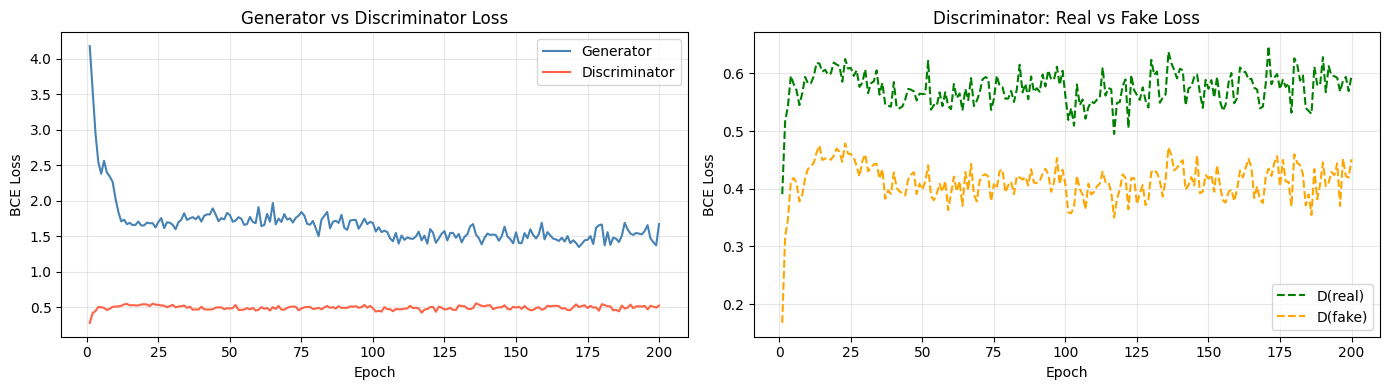

Curvas guardadas.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_range = range(1, len(history["loss_G"]) + 1)

# Loss G vs D
axes[0].plot(epochs_range, history["loss_G"], label="Generator",     color="steelblue")
axes[0].plot(epochs_range, history["loss_D"], label="Discriminator", color="tomato")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Generator vs Discriminator Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# D decomposição
axes[1].plot(epochs_range, history["loss_D_real"], label="D(real)", color="green",  linestyle="--")
axes[1].plot(epochs_range, history["loss_D_fake"], label="D(fake)", color="orange", linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("BCE Loss")
axes[1].set_title("Discriminator: Real vs Fake Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAMPLE_DIR / "loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Curvas guardadas.")


## Visualização Final das Imagens Geradas

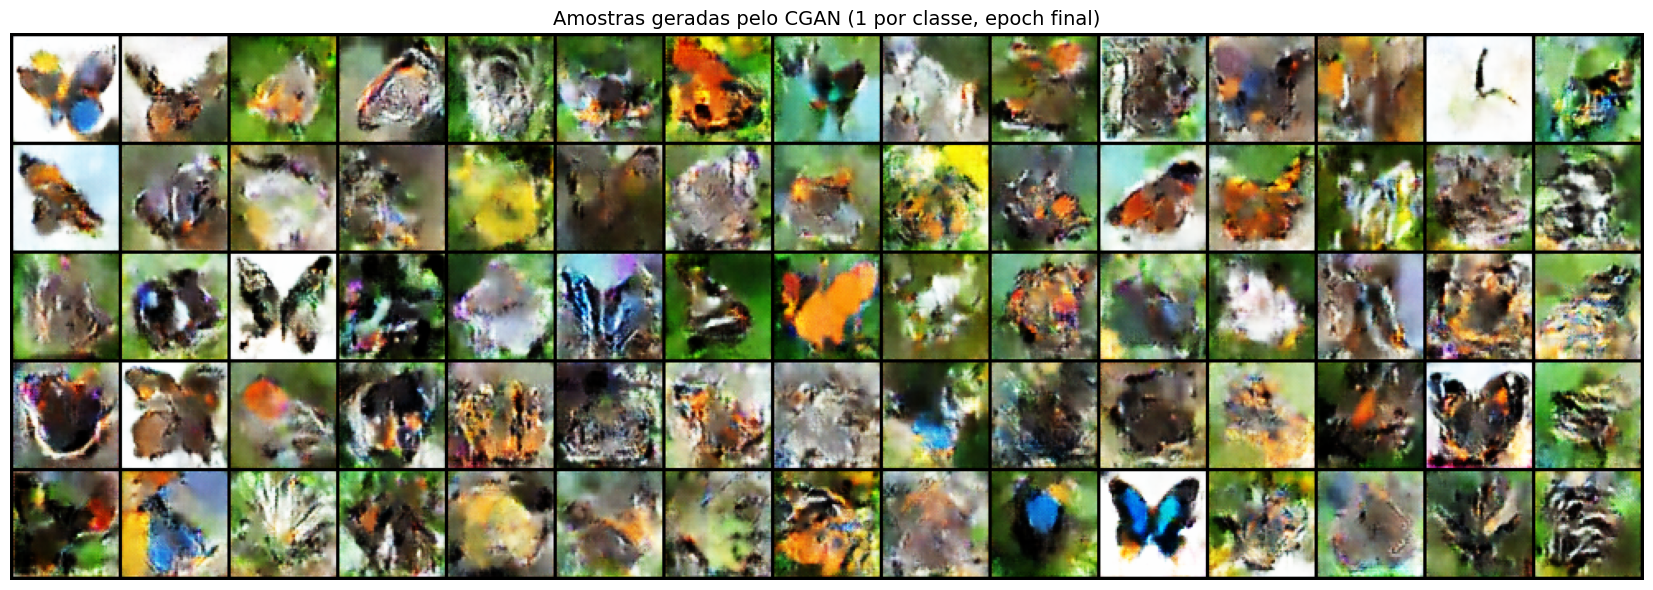

In [15]:
# Carrega o generator final e gera uma grelha de amostras
G.eval()
with torch.no_grad():
    sample_imgs = G(fixed_z, fixed_labels)
    sample_imgs = (sample_imgs * 0.5 + 0.5).clamp(0, 1).cpu()

grid = vutils.make_grid(sample_imgs, nrow=15, padding=2)
fig, ax = plt.subplots(figsize=(20, 6))
ax.imshow(grid.permute(1, 2, 0).numpy())
ax.axis("off")
ax.set_title("Amostras geradas pelo CGAN (1 por classe, epoch final)", fontsize=14)
plt.tight_layout()
plt.savefig(SAMPLE_DIR / "final_samples.png", dpi=150, bbox_inches="tight")
plt.show()


---
# Parte 04 — Gerar Dataset Aumentado

Usa o Generator treinado para criar **N imagens sintéticas por classe** e guarda-as em `data/generated/`.  
O dataset aumentado = imagens originais + imagens geradas.


In [18]:
# ── Configuração da geração ──────────────────────────────────────────────────
N_GENERATED_PER_CLASS = 100     # imagens sintéticas a gerar por classe
GENERATED_DIR = (NOTEBOOK_DIR / "../data/generated").resolve()
AUGMENTED_DIR = (NOTEBOOK_DIR / "../data/augmented").resolve()

GENERATED_DIR.mkdir(parents=True, exist_ok=True)
AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Geradas em  : {GENERATED_DIR}")
print(f"Aumentado em: {AUGMENTED_DIR}")


Geradas em  : /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/generated
Aumentado em: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/augmented


In [19]:
import torchvision.transforms.functional as TF
from PIL import Image as PILImage

# Carregar o generator final (caso o treino já tenha terminado)
G.load_state_dict(torch.load(CKPT_DIR / "generator_final.pt", map_location=device))
G.eval()

idx_to_class = {v: k for k, v in class_to_idx.items()}

# Desnormalizar de [-1,1] para imagem PIL
def tensor_to_pil(t):
    t = (t * 0.5 + 0.5).clamp(0, 1)   # [-1,1] → [0,1]
    return TF.to_pil_image(t.cpu())

generated_records = []   # para o CSV do dataset aumentado

print(f"A gerar {N_GENERATED_PER_CLASS} imagens × {NUM_CLASSES} classes = "
      f"{N_GENERATED_PER_CLASS * NUM_CLASSES} imagens...")

with torch.no_grad():
    for class_idx in range(NUM_CLASSES):
        class_name = idx_to_class[class_idx]
        class_dir  = GENERATED_DIR / class_name.replace(" ", "_")
        class_dir.mkdir(parents=True, exist_ok=True)

        labels = torch.full((N_GENERATED_PER_CLASS,), class_idx,
                            dtype=torch.long, device=device)
        z      = torch.randn(N_GENERATED_PER_CLASS, LATENT_DIM_CFG, device=device)
        imgs   = G(z, labels)   # (N, 3, 64, 64)

        for j, img_t in enumerate(imgs):
            filename = f"{class_name.replace(' ', '_')}_{j:04d}.png"
            filepath = class_dir / filename
            tensor_to_pil(img_t).save(filepath)
            generated_records.append({
                "filename": str(filepath.relative_to(GENERATED_DIR.parent)),
                "label":    class_name,
            })

print(f" {len(generated_records)} imagens geradas e guardadas.")


A gerar 100 imagens × 75 classes = 7500 imagens...
 7500 imagens geradas e guardadas.


In [20]:
# ── Construir CSV do dataset aumentado ──────────────────────────────────────
# Dataset original (train_df já tem 'filename' relativo ao train_dir)
orig_df = train_df[["filename", "label"]].copy()
orig_df["filename"] = orig_df["filename"].apply(
    lambda f: str((train_dir / f).resolve())
)
orig_df["source"] = "original"

gen_df = pd.DataFrame(generated_records)
gen_df["filename"] = gen_df["filename"].apply(
    lambda f: str((GENERATED_DIR.parent / f).resolve())
)
gen_df["source"] = "generated"

augmented_df = pd.concat([orig_df, gen_df], ignore_index=True)
augmented_csv_path = AUGMENTED_DIR / "augmented_train.csv"
augmented_df.to_csv(augmented_csv_path, index=False)

print(f"Dataset aumentado: {len(augmented_df)} imagens "
      f"({len(orig_df)} originais + {len(gen_df)} geradas)")
print(f"CSV guardado em: {augmented_csv_path}")
augmented_df.head()


Dataset aumentado: 11659 imagens (4159 originais + 7500 geradas)
CSV guardado em: /Users/ritapduarte/4ano/2semestre/ACA/aml-butterfly-generative-augmentation/data/augmented/augmented_train.csv


,filename,label,source
0,/Users/ritapduarte/.cache/kagglehub/competitio...,PURPLE HAIRSTREAK,original
1,/Users/ritapduarte/.cache/kagglehub/competitio...,SLEEPY ORANGE,original
2,/Users/ritapduarte/.cache/kagglehub/competitio...,MONARCH,original
3,/Users/ritapduarte/.cache/kagglehub/competitio...,GREAT EGGFLY,original
4,/Users/ritapduarte/.cache/kagglehub/competitio...,SILVER SPOT SKIPPER,original


---
# Parte 05 — Re-treinar a Baseline com Dataset Aumentado

Re-treina a **BaselineCNN sem qualquer alteração** (arquitetura, otimizador e loss idênticos ao baseline original), usando apenas o dataset aumentado.


In [28]:
from models     import BaselineCNN
from transforms import get_transforms
from augmented import AugmentedDataset

# ── Hiperparâmetros de treino (iguais ao baseline original) ──────────────────
BASELINE_EPOCHS    = 50
BASELINE_LR        = 1e-3
BASELINE_BATCH     = 64
EARLY_STOP_PATIENCE = 7

BASELINE_CKPT_DIR = (NOTEBOOK_DIR / "../outputs/checkpoints/baseline_augmented").resolve()
BASELINE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

train_transform, val_transform = get_transforms()

# ── Dataset aumentado (imagens absolutas, sem img_dir prefix) ────────────────
class AugmentedDataset(torch.utils.data.Dataset):
    """Lê imagens por filepath absoluto — compatível com o CSV gerado acima."""
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        classes        = sorted(df["label"].unique())
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = PILImage.open(row["filename"]).convert("RGB")
        if self.transform: image = self.transform(image)
        label = self.class_to_idx[row["label"]]
        return image, torch.tensor(label, dtype=torch.long)

# Split val do dataset aumentado (apenas imagens originais de val para ser justo)
_, val_df_orig = get_splits(train_csv, seed=GLOBAL_SEED)
val_df_orig = val_df_orig.copy()
val_df_orig["filename"] = val_df_orig["filename"].apply(
    lambda f: str((train_dir / f).resolve())
)

aug_train_ds = AugmentedDataset(augmented_df, transform=train_transform)
aug_val_ds   = AugmentedDataset(val_df_orig,  transform=val_transform)

aug_train_loader = DataLoader(aug_train_ds, batch_size=BASELINE_BATCH, shuffle=True,
                               num_workers=4, pin_memory=(device=="cuda"))
aug_val_loader   = DataLoader(aug_val_ds,   batch_size=BASELINE_BATCH, shuffle=False,
                               num_workers=4, pin_memory=(device=="cuda"))

print(f"Treino aumentado : {len(aug_train_ds)} imagens")
print(f"Validação        : {len(aug_val_ds)} imagens")


Treino aumentado : 11659 imagens
Validação        : 1040 imagens


In [32]:
from models     import BaselineCNN
from transforms import get_transforms
from augmented  import AugmentedDataset  # módulo .py já importável

import torch
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, accuracy_score
from tqdm import tqdm

# ── Hyperparameters ─────────────────────────────────────────────
BASELINE_EPOCHS     = 50
BASELINE_LR         = 1e-3
BASELINE_BATCH      = 64
EARLY_STOP_PATIENCE = 7

# ── Transforms ──────────────────────────────────────────────────
train_transform, val_transform = get_transforms()

# ── Datasets ───────────────────────────────────────────────────
_, val_df_orig = get_splits(train_csv, seed=GLOBAL_SEED)
val_df_orig = val_df_orig.copy()
val_df_orig["filename"] = val_df_orig["filename"].apply(lambda f: str((train_dir / f).resolve()))

aug_train_ds = AugmentedDataset(augmented_df, transform=train_transform)
aug_val_ds   = AugmentedDataset(val_df_orig,  transform=val_transform)

# ── DataLoaders com num_workers=0 para evitar erros ─────────────
aug_train_loader = DataLoader(aug_train_ds, batch_size=BASELINE_BATCH,
                              shuffle=True, num_workers=0, pin_memory=(device=="cuda"))
aug_val_loader   = DataLoader(aug_val_ds, batch_size=BASELINE_BATCH,
                              shuffle=False, num_workers=0, pin_memory=(device=="cuda"))

# ── Inicializar modelo, optimizer e loss ─────────────────────────
baseline_aug = BaselineCNN(num_classes=NUM_CLASSES).to(device)
optimizer_b  = torch.optim.Adam(baseline_aug.parameters(), lr=BASELINE_LR)
criterion_b  = torch.nn.CrossEntropyLoss()

best_val_acc   = 0.0
epochs_no_impr = 0

print("Início do treino da Baseline com dataset aumentado...")

for epoch in range(BASELINE_EPOCHS):
    # Treino
    baseline_aug.train()
    t_loss, t_correct, t_total = 0., 0, 0
    for imgs, labels in tqdm(aug_train_loader, desc=f'Epoch {epoch+1}/{BASELINE_EPOCHS}', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_b.zero_grad()
        logits = baseline_aug(imgs)
        loss = criterion_b(logits, labels)
        loss.backward()
        optimizer_b.step()

        t_loss += loss.item() * imgs.size(0)
        t_correct += (logits.argmax(1) == labels).sum().item()
        t_total += imgs.size(0)

    train_acc = t_correct / t_total
    train_loss = t_loss / t_total

    # Validação
    baseline_aug.eval()
    v_loss, v_correct, v_total = 0., 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in aug_val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = baseline_aug(imgs)
            v_loss += criterion_b(logits, labels).item() * imgs.size(0)
            v_correct += (logits.argmax(1) == labels).sum().item()
            v_total += imgs.size(0)

            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = v_correct / v_total
    val_loss = v_loss / v_total
    val_f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Epoch {epoch+1:02d}/{BASELINE_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

    # Guardar melhor modelo e early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_impr = 0
        torch.save(baseline_aug.state_dict(), BASELINE_CKPT_DIR / "baseline_augmented_best.pt")
        print(f"   Best model saved (Val Acc={best_val_acc:.4f})")
    else:
        epochs_no_impr += 1
        if epochs_no_impr >= EARLY_STOP_PATIENCE:
            print(f"Early stopping na epoch {epoch+1}")
            break

print(f"\nTreino finalizado! Melhor Val Acc: {best_val_acc:.4f}")

Início do treino da Baseline com dataset aumentado...


Epoch 01/50 | Train Loss: 3.7001 | Train Acc: 0.0849 | Val Loss: 4.2320 | Val Acc: 0.0567 | F1: 0.0243
   Best model saved (Val Acc=0.0567)


Epoch 02/50 | Train Loss: 2.9368 | Train Acc: 0.2365 | Val Loss: 3.5910 | Val Acc: 0.1125 | F1: 0.0936
   Best model saved (Val Acc=0.1125)


Epoch 03/50 | Train Loss: 2.3931 | Train Acc: 0.3791 | Val Loss: 3.3500 | Val Acc: 0.1548 | F1: 0.1230
   Best model saved (Val Acc=0.1548)


Epoch 04/50 | Train Loss: 1.9701 | Train Acc: 0.5060 | Val Loss: 3.1051 | Val Acc: 0.1952 | F1: 0.1726
   Best model saved (Val Acc=0.1952)


...

Epoch 46/50 | Train Loss: 0.4723 | Train Acc: 0.8558 | Val Loss: 1.2660 | Val Acc: 0.6279 | F1: 0.6123


Epoch 47/50 | Train Loss: 0.4828 | Train Acc: 0.8511 | Val Loss: 1.2022 | Val Acc: 0.6279 | F1: 0.6185


Epoch 48/50 | Train Loss: 0.4537 | Train Acc: 0.8605 | Val Loss: 1.1206 | Val Acc: 0.6692 | F1: 0.6580
   Best model saved (Val Acc=0.6692)


Epoch 49/50 | Train Loss: 0.4859 | Train Acc: 0.8516 | Val Loss: 1.1232 | Val Acc: 0.6606 | F1: 0.6608


Epoch 50/50 | Train Loss: 0.4577 | Train Acc: 0.8582 | Val Loss: 1.4229 | Val Acc: 0.5913 | F1: 0.5869

Treino finalizado! Melhor Val Acc: 0.6692


---
# Parte 06 — Avaliação e Plots

Calcula métricas de qualidade das imagens geradas:
- **FID** (Fréchet Inception Distance) — distância entre distribuições real e gerada (↓ melhor)
- **IS** (Inception Score) — qualidade + diversidade (↑ melhor)
- **SSIM** (Structural Similarity Index) — similaridade estrutural (↑ melhor)

E compara a performance do classificador **antes e depois** da augmentação.


In [33]:
# Instalar pytorch-fid se necessário
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pytorch-fid", "scikit-image",
                "--quiet"], check=True)
print("Dependências instaladas.")


Dependências instaladas.


In [34]:
import warnings
warnings.filterwarnings("ignore")
from skimage.metrics import structural_similarity as ssim_fn
import torchvision.models as tv_models
import torch.nn.functional as F
from scipy import linalg

# ── Inception v3 para FID e IS ───────────────────────────────────────────────
inception = tv_models.inception_v3(weights="DEFAULT", transform_input=False).to(device)
inception.eval()

def get_inception_features(imgs_tensor):
    """Extrai features do penúltimo layer do Inception v3. imgs ∈ [0,1], (N,3,H,W)."""
    imgs_299 = F.interpolate(imgs_tensor, size=(299, 299), mode="bilinear", align_corners=False)
    with torch.no_grad():
        # Hook no avgpool para obter features 2048-d
        feats = []
        def hook(m, i, o): feats.append(o.squeeze(-1).squeeze(-1))
        h = inception.avgpool.register_forward_hook(hook)
        inception(imgs_299.to(device))
        h.remove()
    return feats[0].cpu().numpy()

def compute_fid(real_feats, fake_feats):
    """FID entre dois conjuntos de features numpy."""
    mu1, sigma1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

def compute_is(fake_feats_logits, splits=10):
    """Inception Score a partir dos logits do Inception (antes do softmax)."""
    pyx  = torch.softmax(torch.tensor(fake_feats_logits), dim=1).numpy()
    py   = pyx.mean(0)
    kl   = pyx * (np.log(pyx + 1e-8) - np.log(py + 1e-8))
    scores = np.exp(kl.sum(1))
    chunks = np.array_split(scores, splits)
    return float(np.mean([c.mean() for c in chunks])), float(np.std([c.mean() for c in chunks]))

print("Funções de avaliação definidas.")


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /Users/ritapduarte/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:10<00:00, 10.8MB/s] 


Funções de avaliação definidas.


In [35]:
# ── Recolher features de imagens REAIS ───────────────────────────────────────
real_transform = T.Compose([T.Resize((64, 64)), T.ToTensor()])
real_sample_df = train_df.sample(min(500, len(train_df)), random_state=GLOBAL_SEED)

real_tensors = []
for _, row in real_sample_df.iterrows():
    img = PILImage.open(train_dir / row["filename"]).convert("RGB")
    real_tensors.append(real_transform(img))
real_tensors = torch.stack(real_tensors)   # (N, 3, 64, 64)

real_feats = get_inception_features(real_tensors)
print(f"Features reais: {real_feats.shape}")

# ── Gerar imagens FALSAS para avaliação ──────────────────────────────────────
G.eval()
fake_tensors = []
with torch.no_grad():
    for class_idx in range(NUM_CLASSES):
        n   = max(1, 500 // NUM_CLASSES)
        lbl = torch.full((n,), class_idx, dtype=torch.long, device=device)
        z   = torch.randn(n, LATENT_DIM_CFG, device=device)
        out = G(z, lbl)                        # [-1, 1]
        out = (out * 0.5 + 0.5).clamp(0, 1)   # [0, 1]
        fake_tensors.append(out.cpu())
fake_tensors = torch.cat(fake_tensors)   # (~500, 3, 64, 64)

fake_feats = get_inception_features(fake_tensors)
print(f"Features geradas: {fake_feats.shape}")


Features reais: (500, 2048)
Features geradas: (450, 2048)


In [36]:
# ── FID ──────────────────────────────────────────────────────────────────────
fid_score = compute_fid(real_feats, fake_feats)
print(f"FID  : {fid_score:.2f}   (↓ melhor; <50 é razoável para 64×64)")

# ── IS ───────────────────────────────────────────────────────────────────────
# Para IS precisamos dos logits completos do Inception
fake_logits = []
with torch.no_grad():
    for i in range(0, len(fake_tensors), 64):
        batch = fake_tensors[i:i+64]
        batch_299 = F.interpolate(batch, size=(299,299), mode="bilinear", align_corners=False)
        logits = inception(batch_299.to(device)).cpu().numpy()
        fake_logits.append(logits)
fake_logits = np.concatenate(fake_logits)

is_mean, is_std = compute_is(fake_logits)
print(f"IS   : {is_mean:.2f} ± {is_std:.2f}   (↑ melhor)")

# ── SSIM ─────────────────────────────────────────────────────────────────────
n_pairs = min(200, len(real_tensors), len(fake_tensors))
ssim_scores = []
for i in range(n_pairs):
    r = real_tensors[i].permute(1,2,0).numpy()
    f = fake_tensors[i].permute(1,2,0).numpy()
    ssim_scores.append(ssim_fn(r, f, data_range=1.0, channel_axis=2))

ssim_mean = float(np.mean(ssim_scores))
print(f"SSIM : {ssim_mean:.4f}   (↑ melhor; 1.0 = idêntico)")


FID  : 223.98   (↓ melhor; <50 é razoável para 64×64)
IS   : 3.18 ± 1.29   (↑ melhor)
SSIM : 0.0581   (↑ melhor; 1.0 = idêntico)


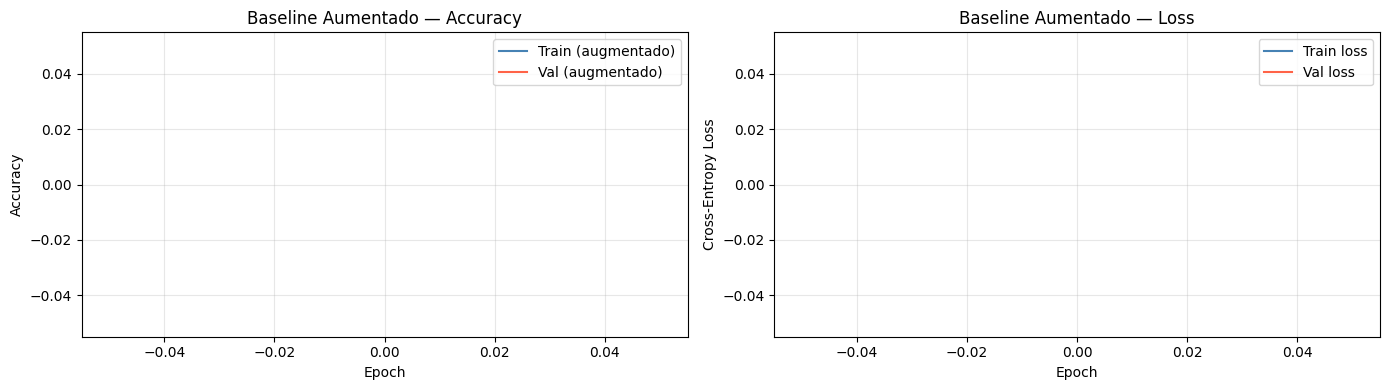


── Resumo de Métricas ──────────────────────────────────────────
  FID  (GAN)                : 223.98
  IS   (GAN)                : 3.18 ± 1.29
  SSIM (GAN vs Real)        : 0.0581
  Best val_acc (augmentado) : 0.6692
────────────────────────────────────────────────────────────────


In [37]:
# ── Curvas de treino: Baseline original vs Baseline aumentado ─────────────────
# Nota: baseline_orig_history deve vir do notebook 01 se o correres separadamente.
# Aqui assumimos que tens baseline_history do treino acima.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_aug = range(1, len(baseline_history["val_acc"]) + 1)

axes[0].plot(epochs_aug, baseline_history["train_acc"], label="Train (augmentado)", color="steelblue")
axes[0].plot(epochs_aug, baseline_history["val_acc"],   label="Val (augmentado)",   color="tomato")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline Aumentado — Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_aug, baseline_history["train_loss"], label="Train loss", color="steelblue")
axes[1].plot(epochs_aug, baseline_history["val_loss"],   label="Val loss",   color="tomato")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Cross-Entropy Loss")
axes[1].set_title("Baseline Aumentado — Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAMPLE_DIR / "baseline_augmented_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tabela resumo ─────────────────────────────────────────────────────────────
print("\n── Resumo de Métricas ──────────────────────────────────────────")
print(f"  FID  (GAN)                : {fid_score:.2f}")
print(f"  IS   (GAN)                : {is_mean:.2f} ± {is_std:.2f}")
print(f"  SSIM (GAN vs Real)        : {ssim_mean:.4f}")
print(f"  Best val_acc (augmentado) : {best_val_acc:.4f}")
print("────────────────────────────────────────────────────────────────")
